# Assignment 2: GAN and Diffusion Model
## Section 3: Denoising Diffusion Probabilistic Model

### Prasanna Paithankar (21CS30065)

11th March 2026

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)
batch_size = 64
lr = 1e-3
epochs = 10

In [3]:
def forward_diffusion(x0, t, noise):
    a_bar = alpha_bar[t].view(-1, 1, 1, 1).to(x0.device)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

mnist_data = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
dataloader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True, drop_last=True)

In [5]:
class DiffUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        self.mid = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU()
        )

        self.dec1 = nn.ConvTranspose2d(
            128, 64, kernel_size=3, stride=2, padding=1, output_padding=0
        )
        self.dec2 = nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec3 = nn.ConvTranspose2d(
            32, 1, kernel_size=3, stride=2, padding=1, output_padding=1
        )

    def forward(self, x, t):
        t_channel = t.view(-1, 1, 1, 1).expand(-1, 1, x.shape[2], x.shape[3])
        x = torch.cat([x, t_channel], dim=1)

        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(e1))
        e3 = torch.relu(self.enc3(e2))

        m = self.mid(e3)

        d1 = torch.relu(self.dec1(m))
        d2 = torch.relu(self.dec2(d1))
        d3 = self.dec3(d2)

        return d3

In [6]:
def trainer(model, epochs=epochs, lr=lr):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    global_beta = beta.to(device)
    global_alpha_bar = alpha_bar.to(device)
    losses = []

    with Progress() as progress:
        epoch_task = progress.add_task("[cyan]Training[/cyan]", total=epochs)
        for epoch in range(epochs):
            epoch_loss = 0
            for images, _ in dataloader:
                images = images.to(device)

                t = torch.randint(0, T, (images.shape[0],), device=device)
                noise = torch.randn_like(images)

                noisy_images = forward_diffusion(images, t, noise)

                t_normalized = t.float() / T
                predicted_noise = model(noisy_images, t_normalized)

                loss = criterion(predicted_noise, noise)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            losses.append(epoch_loss / len(dataloader))
            progress.update(
                epoch_task,
                advance=1,
                description=f"[cyan]Epoch {epoch + 1}/{epochs}[/cyan] Loss: {epoch_loss:.4f}",
            )

    return losses

In [7]:
model = DiffUNet().to(device)

losses = trainer(model)

torch.save(model.state_dict(), "diffunet.pth")

Output()

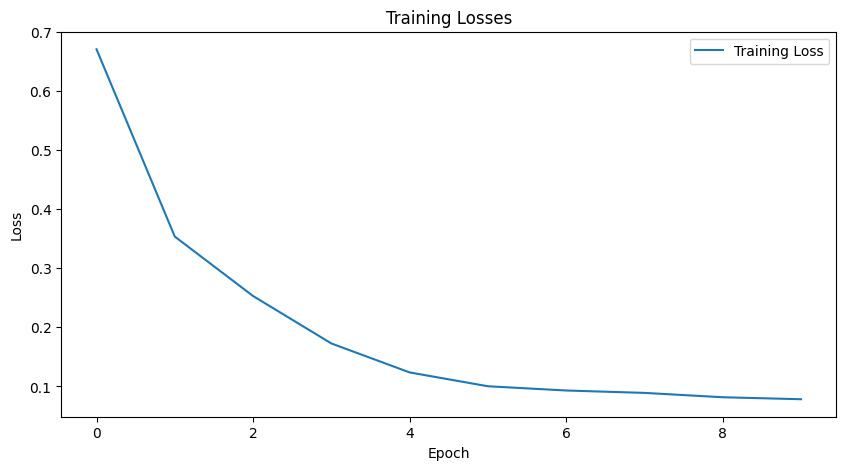

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

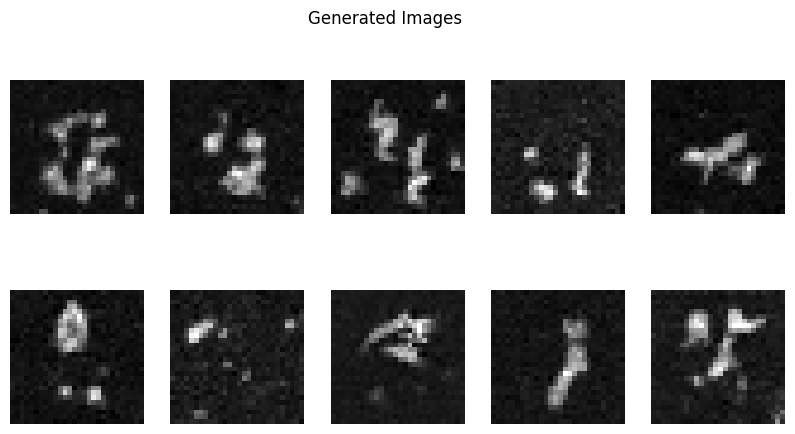

In [9]:
model.eval()
final_images = []

for i in range(10):
    with torch.no_grad():
        x = torch.randn(1, 1, 28, 28).to(device)

        for i in reversed(range(T)):
            t_tensor = torch.tensor([i], device=device)
            t_norm = t_tensor.float() / T

            predicted_noise = model(x, t_norm)

            alpha_t = alpha[i].to(device)
            alpha_bar_t = alpha_bar[i].to(device)
            beta_t = beta[i].to(device)

            if i > 0:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            x = (1 / torch.sqrt(alpha_t)) * (
                x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
            ) + torch.sqrt(beta_t) * z

    final_images.append(x.cpu().squeeze().numpy())

plt.figure(figsize=(10, 5))
for i, img in enumerate(final_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
plt.suptitle("Generated Images")
plt.show()

***